# Test with a real data

In [1]:
import xarray as xr
import glob

from pcmdi_metrics.effective_resolution import compute_effective_resolution
import matplotlib.pyplot as plt
import numpy as np

## Prepare input

In [2]:
#datadir = "/global/cfs/cdirs/m4581/lee1043/DATA/CMIP6/HighResMIP/ECMWF-IFS-LR/hist-1950/6hrPlevPt"
#datadir = "/global/cfs/cdirs/m4581/lee1043/DATA/CMIP6/HighResMIP/ECMWF-IFS-LR/highresSST-present/6hrPlevPt"
#datadir = "/home/lee1043/work/DATA/HighResMIP/ECMWF-IFS-LR/hist-1950/6hrPlevPt"
#datadir = "/home/lee1043/work/DATA/HighResMIP/ECMWF-IFS-LR/highresSST-present/6hrPlevPt"
datadir = "/Users/lee1043/Documents/Research/DATA/HighResMIP/ECMWF-IFS-LR/highresSST-present/6hrPlevPt"

In [3]:
data_list = sorted(glob.glob(f"{datadir}/*/*ECMWF-IFS-LR*_2014*.nc"))
data_list

['/Users/lee1043/Documents/Research/DATA/HighResMIP/ECMWF-IFS-LR/highresSST-present/6hrPlevPt/ua/ua_6hrPlevPt_ECMWF-IFS-LR_highresSST-present_r1i1p1f1_gr_201401010000-201401311800.nc',
 '/Users/lee1043/Documents/Research/DATA/HighResMIP/ECMWF-IFS-LR/highresSST-present/6hrPlevPt/ua/ua_6hrPlevPt_ECMWF-IFS-LR_highresSST-present_r1i1p1f1_gr_201402010000-201402281800.nc',
 '/Users/lee1043/Documents/Research/DATA/HighResMIP/ECMWF-IFS-LR/highresSST-present/6hrPlevPt/ua/ua_6hrPlevPt_ECMWF-IFS-LR_highresSST-present_r1i1p1f1_gr_201403010000-201403311800.nc',
 '/Users/lee1043/Documents/Research/DATA/HighResMIP/ECMWF-IFS-LR/highresSST-present/6hrPlevPt/ua/ua_6hrPlevPt_ECMWF-IFS-LR_highresSST-present_r1i1p1f1_gr_201404010000-201404301800.nc',
 '/Users/lee1043/Documents/Research/DATA/HighResMIP/ECMWF-IFS-LR/highresSST-present/6hrPlevPt/ua/ua_6hrPlevPt_ECMWF-IFS-LR_highresSST-present_r1i1p1f1_gr_201405010000-201405311800.nc',
 '/Users/lee1043/Documents/Research/DATA/HighResMIP/ECMWF-IFS-LR/highresSST

In [4]:
target_months = ('201403', '201406', '201409', '201412')

data_list = [
    data_path
    for data_path in data_list
    if any(month in data_path for month in target_months)
]

In [5]:
[filepath.split('/')[-1] for filepath in data_list]

['ua_6hrPlevPt_ECMWF-IFS-LR_highresSST-present_r1i1p1f1_gr_201403010000-201403311800.nc',
 'ua_6hrPlevPt_ECMWF-IFS-LR_highresSST-present_r1i1p1f1_gr_201406010000-201406301800.nc',
 'ua_6hrPlevPt_ECMWF-IFS-LR_highresSST-present_r1i1p1f1_gr_201409010000-201409301800.nc',
 'ua_6hrPlevPt_ECMWF-IFS-LR_highresSST-present_r1i1p1f1_gr_201412010000-201412311800.nc',
 'va_6hrPlevPt_ECMWF-IFS-LR_highresSST-present_r1i1p1f1_gr_201403010000-201403311800.nc',
 'va_6hrPlevPt_ECMWF-IFS-LR_highresSST-present_r1i1p1f1_gr_201406010000-201406301800.nc',
 'va_6hrPlevPt_ECMWF-IFS-LR_highresSST-present_r1i1p1f1_gr_201409010000-201409301800.nc',
 'va_6hrPlevPt_ECMWF-IFS-LR_highresSST-present_r1i1p1f1_gr_201412010000-201412311800.nc']

In [6]:
ds = xr.open_mfdataset(data_list)

/var/folders/wh/jt7ywcnn01z8xcrr1p_dzp8r001rcz/T/ipykernel_99433/1960847013.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(data_list)
/var/folders/wh/jt7ywcnn01z8xcrr1p_dzp8r001rcz/T/ipykernel_99433/1960847013.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset

In [7]:
ds

<xarray.Dataset> Size: 2GB
Dimensions:   (time: 488, lat: 181, bnds: 2, lon: 360, plev: 7)
Coordinates:
  * time      (time) datetime64[ns] 4kB 2014-03-01 ... 2014-12-31T18:00:00
  * lat       (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon       (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * plev      (plev) float64 56B 9.25e+04 8.5e+04 7e+04 ... 5e+04 2.5e+04 5e+03
Dimensions without coordinates: bnds
Data variables:
    lat_bnds  (time, lat, bnds) float64 1MB dask.array<chunksize=(124, 181, 2), meta=np.ndarray>
    lon_bnds  (time, lon, bnds) float64 3MB dask.array<chunksize=(124, 360, 2), meta=np.ndarray>
    ua        (time, plev, lat, lon) float32 890MB dask.array<chunksize=(1, 7, 181, 360), meta=np.ndarray>
    va        (time, plev, lat, lon) float32 890MB dask.array<chunksize=(1, 7, 181, 360), meta=np.ndarray>
Attributes: (12/52)
    Conventions:             CF-1.7 CMIP-6.0
    activity_id:             HighResMIP
    branch_method:           no parent
    contact:                 chris.roberts@ecmwf.int
    creation_date:           2017-08-24T14:44:54Z
    end_year:                2014
    ...                      ...
    source_type:             AGCM
    data_specs_version:      01.00.23
    institution:             European Centre for Medium-Range Weather Forecas...
    references:              Roberts, C. D., Senan, R., Molteni, F., Boussett...
    source:                  ECMWF-IFS-LR (2017): \naerosol: none\natmos: IFS...
    history:                 2017-08-24T14:44:54Z CMOR rewrote data to be con...

## Metrics calculation

In [22]:
%%time

metrics, diagnostics = compute_effective_resolution(
    ds,
    uvar="ua",
    vvar="va",
    levels=(250.0, 500.0),
    model="ECMWF-IFS-LR",
    member="r1i1p1f1",
    save_interim_netcdf=False,
)

result = metrics["ECMWF-IFS-LR"]["r1i1p1f1"]
result

CPU times: user 2min 15s, sys: 1.97 s, total: 2min 17s
Wall time: 2min 17s


{'effective_wavenumber': None,
 'effective_resolution_km': None,
 'grid_box_distance_km': 142.92723476062542,
 'resolution_ratio': None,
 'resolution_ratio_dx_convention': None,
 'is_upper_limit': False,
 'n_spectra_steepening': 1,
 'steepening_wavenumber': {'div_250': 59.0, 'rot_250': None, 'rot_500': None},
 'steepening_eddy_scale_km': {'div_250': 336.3998912766091,
  'rot_250': None,
  'rot_500': None},
 'steepening_wavenumber_range': [59.0, 59.0],
 'criterion': {'fit_window': 20,
  'fit_anchor': 'center',
  'steepening_factor': 0.25,
  'wavenumber_ratio': 2.0,
  'min_wavenumber': 32,
  'n_confirm': 2},
 'reference': 'Klaver et al. (2020), doi:10.1002/asl.952'}

Save interim fime for cross validation

In [ ]:
"""
%%time

metrics, diagnostics = compute_effective_resolution(
    ds,
    uvar="ua",
    vvar="va",
    levels=(250.0, 500.0),
    model="ECMWF-IFS-LR",
    member="r1i1p1f1",
    save_interim_netcdf=True,
)

result = metrics["ECMWF-IFS-LR"]["r1i1p1f1"]
result
"""

CPU times: user 8min 32s, sys: 3.94 s, total: 8min 36s
Wall time: 8min 37s


{'effective_wavenumber': None,
 'effective_resolution_km': None,
 'grid_box_distance_km': 142.92723476062542,
 'resolution_ratio': None,
 'resolution_ratio_dx_convention': None,
 'is_upper_limit': False,
 'n_spectra_steepening': 1,
 'steepening_wavenumber': {'div_250': 59.0, 'rot_250': None, 'rot_500': None},
 'steepening_eddy_scale_km': {'div_250': 336.3998912766091,
  'rot_250': None,
  'rot_500': None},
 'steepening_wavenumber_range': [59.0, 59.0],
 'criterion': {'fit_window': 20,
  'fit_anchor': 'center',
  'steepening_factor': 0.25,
  'wavenumber_ratio': 2.0,
  'min_wavenumber': 32,
  'n_confirm': 2},
 'reference': 'Klaver et al. (2020), doi:10.1002/asl.952'}

## Analysis (temporary interim data)

In [10]:
#ds_interim = xr.open_dataset("./output/ke_spectra_interim_ECMWF-IFS-LR_r1i1p1f1.nc")
ds_interim = xr.open_dataset("./output/vorticity_divergence_ECMWF-IFS-LR_r1i1p1f1.nc")

ds_interim

<xarray.Dataset> Size: 1GB
Dimensions:         (time: 488, lat: 181, lon: 360)
Coordinates:
  * time            (time) datetime64[ns] 4kB 2014-03-01 ... 2014-12-31T18:00:00
  * lat             (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 88.0 89.0 90.0
  * lon             (lon) float64 3kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
    plev            float64 8B ...
Data variables:
    vorticity_250   (time, lat, lon) float64 254MB ...
    divergence_250  (time, lat, lon) float64 254MB ...
    vorticity_500   (time, lat, lon) float64 254MB ...
    divergence_500  (time, lat, lon) float64 254MB ...
Attributes:
    model:        ECMWF-IFS-LR
    experiment:   
    member:       r1i1p1f1
    description:  Vorticity and divergence fields from spherical harmonic dec...
    reference:    Klaver et al. (2020), doi:10.1002/asl.952

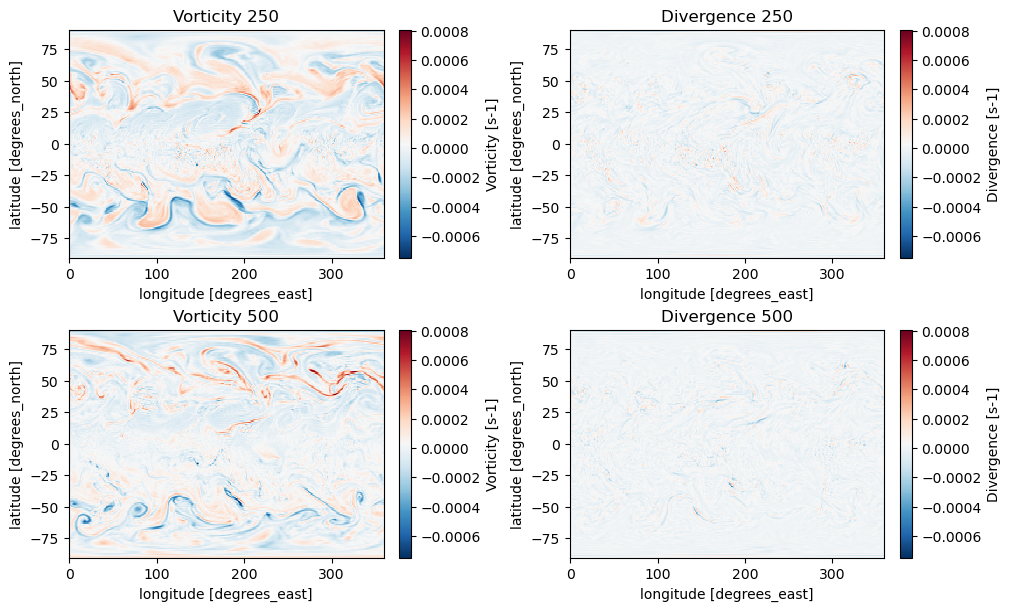

In [11]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(10, 6),
    constrained_layout=True
)

plots = [
    (ds_interim.vorticity_250.isel(time=0), "Vorticity 250"),
    (ds_interim.divergence_250.isel(time=0), "Divergence 250"),
    (ds_interim.vorticity_500.isel(time=0), "Vorticity 500"),
    (ds_interim.divergence_500.isel(time=0), "Divergence 500"),
]

vmin = min(data.min().item() for data, _ in plots)
vmax = max(data.max().item() for data, _ in plots)

for ax, (data, title) in zip(axes.flat, plots):
    data.plot(ax=ax, vmin=vmin, vmax=vmax, cmap="RdBu_r", add_colorbar=True)
    ax.set_title(title)

plt.show()

In [12]:
print("Vorticity 250 hPa statistics:")
print(f"  Min: {ds_interim.vorticity_250.min().values:.2e} s^-1")
print(f"  Max: {ds_interim.vorticity_250.max().values:.2e} s^-1")
print(f"  Std: {ds_interim.vorticity_250.std().values:.2e} s^-1")

print("\nExpected: O(10^-4 to 10^-5) s^-1 for 250 hPa winds")

Vorticity 250 hPa statistics:
  Min: -1.09e-03 s^-1
  Max: 1.30e-03 s^-1
  Std: 1.13e-04 s^-1

Expected: O(10^-4 to 10^-5) s^-1 for 250 hPa winds


## Analysis (diagnostics)

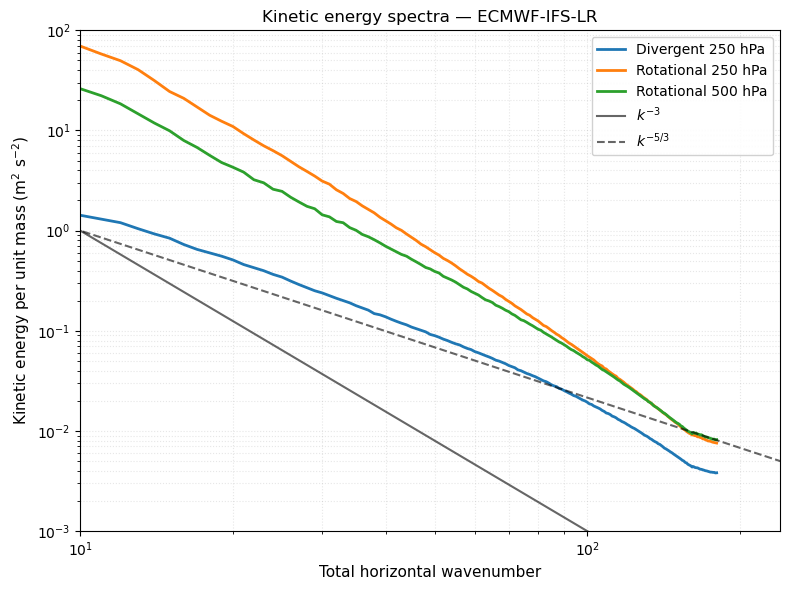

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the kinetic energy spectra
spectra = diagnostics["spectra"]
colors = {"div": "C0", "rot_250": "C1", "rot_500": "C2"}
labels = {"div": "Divergent 250 hPa", "rot_250": "Rotational 250 hPa", 
          "rot_500": "Rotational 500 hPa"}

# Plot divergent at 250 hPa
spec_250 = spectra[250.0]
wavenumber = spec_250["wavenumber"].values
ke_div = spec_250["ke_div"].values
ax.loglog(wavenumber, ke_div, color=colors["div"], linewidth=2, label=labels["div"])

# Plot rotational at 250 hPa
ke_rot_250 = spec_250["ke_rot"].values
ax.loglog(wavenumber, ke_rot_250, color=colors["rot_250"], linewidth=2, label=labels["rot_250"])

# Plot rotational at 500 hPa
spec_500 = spectra[500.0]
ke_rot_500 = spec_500["ke_rot"].values
ax.loglog(wavenumber, ke_rot_500, color=colors["rot_500"], linewidth=2, label=labels["rot_500"])

# Add reference lines for k^-3 and k^-5/3
# Control where reference lines start by specifying y-value at a reference wavenumber
k_ref_start = 10.0       # Reference wavenumber where we set the y-value
y_ref_value = 1e0        # Y-axis value at k_ref_start for both reference lines

k_ref = np.logspace(0, 3, 100)  # wavenumbers from 1 to 1000

# Calculate amplitude to make reference line pass through (k_ref_start, y_ref_value)
# For k^-3: y = A * k^-3, so A = y * k^3
amplitude_k3 = y_ref_value * k_ref_start**3
amplitude_k53 = y_ref_value * k_ref_start**(5/3)

ke_ref_k3 = amplitude_k3 * k_ref**(-3)
ke_ref_k53 = amplitude_k53 * k_ref**(-5/3)

ax.loglog(k_ref, ke_ref_k3, 'k-', linewidth=1.5, alpha=0.6, label=r'$k^{-3}$')
ax.loglog(k_ref, ke_ref_k53, 'k--', linewidth=1.5, alpha=0.6, label=r'$k^{-5/3}$')

ax.set_xlim(10, 240)
ax.set_ylim(1e-3, 1e2)
ax.set_xlabel("Total horizontal wavenumber", fontsize=11)
ax.set_ylabel(r"Kinetic energy per unit mass (m$^2$ s$^{-2}$)", fontsize=11)
ax.legend(loc="upper right", frameon=True, framealpha=0.9)
ax.grid(True, which="both", alpha=0.3, linestyle=":")
ax.set_title("Kinetic energy spectra — ECMWF-IFS-LR", fontsize=12)

plt.tight_layout()
plt.show()

In [17]:
metrics

{'ECMWF-IFS-LR': {'r1i1p1f1': {'effective_wavenumber': None,
   'effective_resolution_km': None,
   'grid_box_distance_km': 142.92723476062542,
   'resolution_ratio': None,
   'resolution_ratio_dx_convention': None,
   'is_upper_limit': False,
   'n_spectra_steepening': 1,
   'steepening_wavenumber': {'div_250': 59.0,
    'rot_250': None,
    'rot_500': None},
   'steepening_eddy_scale_km': {'div_250': 336.3998912766091,
    'rot_250': None,
    'rot_500': None},
   'steepening_wavenumber_range': [59.0, 59.0],
   'criterion': {'fit_window': 20,
    'fit_anchor': 'center',
    'steepening_factor': 0.25,
    'wavenumber_ratio': 2.0,
    'min_wavenumber': 32,
    'n_confirm': 2},
   'reference': 'Klaver et al. (2020), doi:10.1002/asl.952'}}}

### Compensated vs. Uncompensated Spectra

The `plot_spectra_and_slope` function supports both:

1. **Compensated spectra** (default, `compensate=3.0`): Reproduces Figure 1 from Klaver et al. (2020)
   - Y-axis shows $l^3 E_l$, making a $k^{-3}$ spectrum appear flat
   - Highlights deviations from the reference power laws
   - Easier to see spectral steepening

2. **Uncompensated spectra** (`compensate=None` or `compensate=0`): Reproduces Figure S3 from supplementary material
   - Y-axis shows raw spectrum in m²/s²
   - Power-law slopes appear as straight lines in log-log space
   - Shows the full dynamic range of the spectra

Both styles show the same data but emphasize different aspects of the spectral behavior.

In [24]:
from pcmdi_metrics.effective_resolution.lib import (
    plot_spectra_and_slope,
)

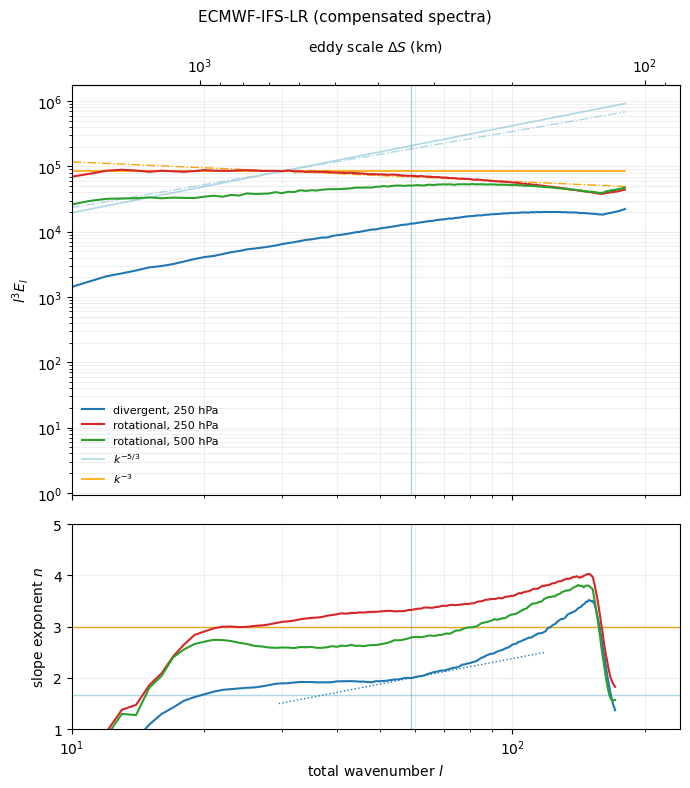

In [21]:
# Test uncompensated spectra (Figure S3 style)
# Set compensate=None or compensate=0 to plot without l^-3 compensation
fig = plot_spectra_and_slope(
    diagnostics, 
    result,
    #compensate=None,         # Turn OFF compensation (Figure S3)
    xlim=(10, 240),          # Wavenumber range
    #spec_ylim=(1e-2, 1e2),   # Uncompensated spectrum y-range
    slope_ylim=(1, 5),       # Slope panel y-range
    title="ECMWF-IFS-LR (compensated spectra)"
)
plt.show()

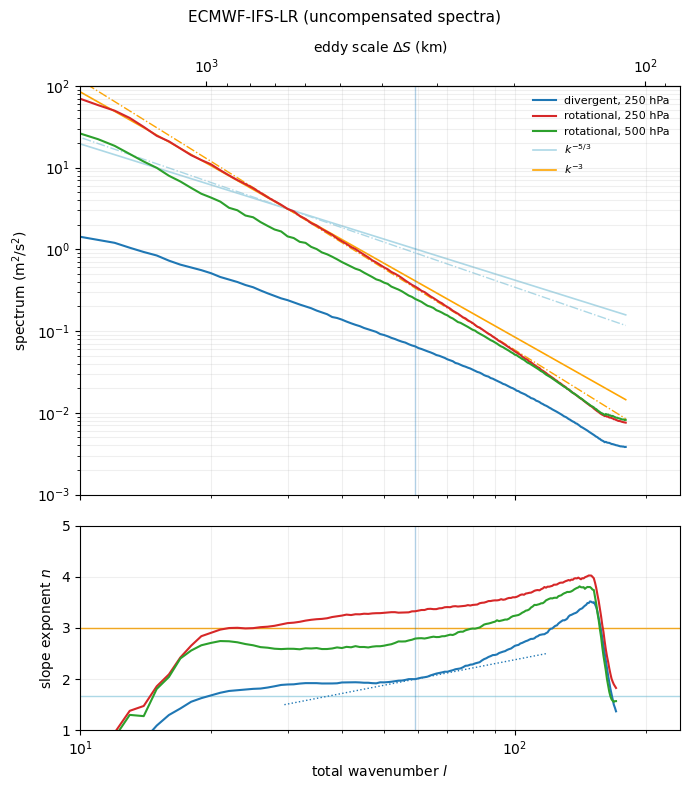

In [26]:
# Test uncompensated spectra (Figure S3 style)
# Set compensate=None or compensate=0 to plot without l^-3 compensation
fig = plot_spectra_and_slope(
    diagnostics, 
    result,
    compensate=None,         # Turn OFF compensation (Figure S3)
    xlim=(10, 240),          # Wavenumber range
    spec_ylim=(1e-3, 1e2),   # Uncompensated spectrum y-range
    slope_ylim=(1, 5),       # Slope panel y-range
    title="ECMWF-IFS-LR (uncompensated spectra)"
)
plt.show()

## Figure 2 — Effective vs. Nominal Resolution Scatter Plot

This reproduces Figure 2 from Klaver et al. (2020), showing the relationship between effective resolution (L_eff) and grid box distance (L_box). The ratio L_eff/L_box is color-coded and ranges from 2.7 to 4.8 across the HighResMIP models in the paper.

**Note**: This example shows only one configuration (ECMWF-IFS-LR regridded to 1°). The scatter plot is most useful when comparing multiple models or resolution configurations of the same model (e.g., LR vs HR versions).

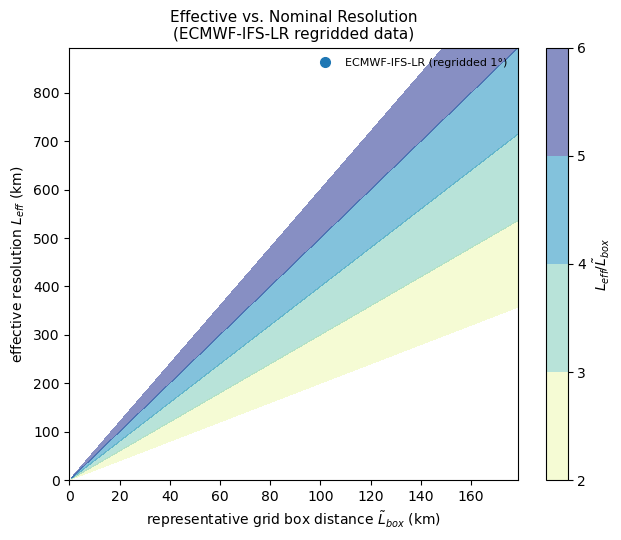


Note: This data point shows:
  - Grid box distance: 142.9 km (1° regridded grid)
  - Effective resolution: None (None - insufficient steepening)
  - Only 1 of 3 spectra steepened (need 2+ for confirmation)

From Klaver et al. Table 1, native ECMWF-IFS-LR should have:
  - Grid box distance: 79.6 km (TCO199 reduced Gaussian)
  - Effective wavenumber: l=79
  - Effective resolution: 253 km
  - Ratio: 3.2


In [ ]:
from pcmdi_metrics.effective_resolution.lib import plot_resolution_scatter

# For this example, we only have one model configuration
# In practice, you would have multiple models or configurations to compare
ensemble = [result]
labels = ["ECMWF-IFS-LR (regridded 1°)"]

# Note: The plot shows this is regridded data (not native grid)
# The effective resolution couldn't be determined (None) because only 1 spectrum steepened
# For proper analysis, use native grid data (gn) instead of regridded (gr)

fig = plot_resolution_scatter(
    ensemble, 
    labels=labels, 
    title="Effective vs. Nominal Resolution\n(ECMWF-IFS-LR regridded data)"
)
plt.show()

print("\nNote: This data point shows:")
print(f"  - Grid box distance: {result['grid_box_distance_km']:.1f} km (1° regridded grid)")
print(f"  - Effective resolution: {result['effective_resolution_km']} (None - insufficient steepening)")
print(f"  - Only 1 of 3 spectra steepened (need 2+ for confirmation)")
print("\nFrom Klaver et al. Table 1, native ECMWF-IFS-LR should have:")
print("  - Grid box distance: 79.6 km (TCO199 reduced Gaussian)")
print("  - Effective wavenumber: l=79")
print("  - Effective resolution: 253 km")
print("  - Ratio: 3.2")